# A) Import

In [792]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [793]:
mois = "Dec2025"  

In [794]:
route = f"C:\\Users\\hp\\Desktop\\ISJ\\projet tutore\\{mois}.csv"
df = pd.read_csv(route,sep=';', on_bad_lines='warn',low_memory=False)
df.head()


C:\Users\hp\AppData\Local\Temp\ipykernel_5748\3453768675.py:2: ParserWarning:

Skipping line 84130: expected 8 fields, saw 9




,sensor_id,sensor_type,location,lat,lon,timestamp,value_type,value
0,4930,pms5003,3981,-1.269,36.819,2025-12-01T00:00:00.931399+00:00,P2,22.60
1,4930,pms5003,3981,-1.269,36.819,2025-12-01T00:00:00.931399+00:00,P1,25.20
2,4930,pms5003,3981,-1.269,36.819,2025-12-01T00:00:00.931399+00:00,P0,15.00
3,4931,DHT22,3981,-1.269,36.819,2025-12-01T00:00:18.348581+00:00,humidity,73.60
4,4931,DHT22,3981,-1.269,36.819,2025-12-01T00:00:18.348581+00:00,temperature,18.10


# B) Exploration des donnees et ETL

## **initialisation**

In [795]:
data = df.copy()

In [796]:
data.shape

(152399, 8)

In [797]:
data["value_type"].unique()

array(['P2', 'P1', 'P0', 'humidity', 'temperature'], dtype=object)

Dans un premier temps on va se separer de la colonne Unnamed: 8 et des valeurs de "noise_Leq"

Pour le moment pour un soucis de volumetrie, on est contraint de laisser d'abord le parametre  
environnemental **"noise_Leq"**. Regardons maintenant humidity et temperature.

## **Process**

Voici comment nous comptons organiser la transformation des données dans notre projet :

**Actuellement, nos données sont structurées en "format long" (tidy) :**
- Chaque ligne correspond à la mesure d’un seul paramètre (P2, P1, P0, humidity, temperature) pour un capteur donné à un horodatage précis
- Les mesures de particules (P2/P1/P0) et celles d’humidité/température ont des timestamps légèrement décalés (de 0 à 3 secondes)

**Notre objectif est de passer à un "format large" (format croisé) :**
- Une ligne = un instant principal (le timestamp des mesures de particules)
- Des colonnes distinctes pour chaque paramètre : P2, P1, P0
- 4 jeux de donnees en fonctions des 4 locations
- Garder les métadonnées spatiales : location, lat, lon
- Aligner les mesures qui ont jusqu’à 3 secondes d’écart sur le même timestamp principal

**Le défi principal** sera de bien grouper les mesures prises à quelques secondes près pour les traiter comme une observation simultanée.

In [798]:
data=df.copy()

In [799]:
data = data[data["value_type"]!="noise_Leq"]

In [800]:
data.shape

(152399, 8)

In [801]:
data.duplicated().sum()

2098

In [802]:
data=data.drop_duplicates()
data.shape[0]

150301

In [803]:
data.duplicated().sum()

0

In [804]:
df1= data[data["value_type"]=="P2"]
df1.shape[0]

30374

In [805]:
df2= data[data["value_type"]=="P1"]
df2.shape[0]

30373

In [806]:
df3= data[data["value_type"]=="P0"]
df3.shape[0]

30372

In [807]:
df4= data[data["value_type"]=="humidity"]
df4.shape[0]

29591

In [808]:
df5= data[data["value_type"]=="temperature"]
df5.shape[0]

29591

De facon globale nous avons par mois a peu pret 26000 enregistrements de chaque particule.

In [809]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150301 entries, 0 to 152398
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   sensor_id    150301 non-null  int64  
 1   sensor_type  150301 non-null  object 
 2   location     150301 non-null  int64  
 3   lat          150301 non-null  float64
 4   lon          150301 non-null  float64
 5   timestamp    150301 non-null  object 
 6   value_type   150301 non-null  object 
 7   value        150301 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 10.3+ MB


In [810]:
if data.shape[1]==9:
    data=data.drop(columns=["Colonne1"])

In [811]:
data["location"].unique()

array([3981,   76, 3966, 3967], dtype=int64)

In [812]:
locations = sorted(list(data["location"].unique()))

In [813]:
locations

[76, 3966, 3967, 3981]

In [814]:
data["value"]=pd.to_numeric(data["value"],errors="coerce")
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150301 entries, 0 to 152398
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   sensor_id    150301 non-null  int64  
 1   sensor_type  150301 non-null  object 
 2   location     150301 non-null  int64  
 3   lat          150301 non-null  float64
 4   lon          150301 non-null  float64
 5   timestamp    150301 non-null  object 
 6   value_type   150301 non-null  object 
 7   value        150274 non-null  float64
dtypes: float64(3), int64(2), object(3)
memory usage: 10.3+ MB


On va effectuer un travail horizontal, en divisant deja nos donnees par location

In [815]:
# Création des 5 jeux de données séparés par location
data_par_location = {}

for loc in locations:
    # 1. Filtrer les données pour la location
    df_loc = data[data['location'] == loc].copy()
    
    # 2. Optionnel : Trier par timestamp pour plus de clarté
    df_loc = df_loc.sort_values('timestamp').reset_index(drop=True)
    
    # 3. Stocker dans le dictionnaire
    data_par_location[loc] = df_loc
    
    # 4. Afficher un résumé
    print(f"Location {loc}: {len(df_loc)} lignes")
    print(f"  Capteurs uniques : {df_loc['sensor_id'].unique().tolist()}")
    print(f"  Types de mesures : {df_loc['value_type'].unique().tolist()}")

Location 76: 52413 lignes
  Capteurs uniques : [4962, 4963, 4976, 4977]
  Types de mesures : ['P2', 'P1', 'P0', 'humidity', 'temperature']
Location 3966: 36919 lignes
  Capteurs uniques : [4899, 4898]
  Types de mesures : ['humidity', 'temperature', 'P2', 'P1', 'P0']
Location 3967: 7341 lignes
  Capteurs uniques : [4900, 4901]
  Types de mesures : ['P2', 'P1', 'P0', 'humidity', 'temperature']
Location 3981: 53628 lignes
  Capteurs uniques : [4930, 4931, 792, 793]
  Types de mesures : ['P2', 'P1', 'P0', 'humidity', 'temperature']


In [816]:
# Test : Nombre de capteurs uniques par timestamp
test = data_par_location[locations[0]].groupby('timestamp')['sensor_id'].nunique()

# Résumé
print("=== RÉSULTAT DU TEST ===")
print(f"Nombre total de timestamps uniques : {len(test)}")
print(f"Nombre de timestamps avec >1 capteur : {(test > 1).sum()}")

# Détail des timestamps problématiques (si existants)
if (test > 1).any():
    print(f"\n⚠️  Problème détecté ! Exemples de timestamps avec plusieurs capteurs :")
    print(test[test > 1].head())
else:
    print(f"\n✅ Confirmation : Chaque timestamp est associé à un seul capteur.")

=== RÉSULTAT DU TEST ===
Nombre total de timestamps uniques : 20958
Nombre de timestamps avec >1 capteur : 14

⚠️  Problème détecté ! Exemples de timestamps avec plusieurs capteurs :
timestamp
2025-12-07T15:23:57+00:00    2
2025-12-08T02:05:48+00:00    2
2025-12-13T01:24:07+00:00    2
2025-12-14T20:43:48+00:00    2
2025-12-16T16:48:33+00:00    2
Name: sensor_id, dtype: int64


In [817]:
def preparer_jeu_final_fusion(df_location):
    """Fusionne les mesures de différents capteurs qui partagent le même timestamp"""
    # 1. Pivot
    df_pivot = df_location.pivot_table(
        index=['timestamp', 'sensor_id'],
        columns='value_type',
        values='value',
        aggfunc='first'
    ).reset_index()
    df_pivot.columns.name = None
    
    # 2. Fusion
    def combiner_lignes(groupe):
        if len(groupe) == 1:
            return groupe
        
        # Créer un dictionnaire pour la ligne fusionnée
        ligne_fusion = {}
        ligne_fusion['timestamp'] = groupe['timestamp'].iloc[0]
        
        for col in ['P0', 'P1', 'P2', 'humidity', 'temperature']:
            if col in groupe.columns:
                valeurs = groupe[col].dropna()
                ligne_fusion[col] = valeurs.iloc[0] if len(valeurs) > 0 else np.nan
        
        ligne_fusion['sensor_id'] = tuple(groupe['sensor_id'].unique())
        
        # Retourner un DataFrame d'une seule ligne
        return pd.DataFrame([ligne_fusion])
    
    # 3. Appliquer la fusion
    df_fusionne = pd.concat(
        [combiner_lignes(groupe) for _, groupe in df_pivot.groupby('timestamp')],
        ignore_index=True
    )
    
    # 4. Réorganiser colonnes
    colonnes = ['timestamp', 'sensor_id', 'P0', 'P1', 'P2', 'humidity', 'temperature']
    colonnes_existantes = [col for col in colonnes if col in df_fusionne.columns]
    return df_fusionne[colonnes_existantes]



In [818]:
# Appliquer la fonction à tous les jeux de données
final_par_location = {}

for loc in data_par_location.keys():
    final_par_location[loc] = preparer_jeu_final_fusion(data_par_location[loc])
    
    # Afficher les résultats
    print(f"Location {loc}:")
    print(f"  - Shape: {final_par_location[loc].shape}")
    print(f"  - Timestamp range: {final_par_location[loc]['timestamp'].min()} -> {final_par_location[loc]['timestamp'].max()}")
    
    # Vérifier les valeurs manquantes
    missing = final_par_location[loc][['P2', 'humidity']].isnull().sum()
    print(f"  - P2 manquants: {missing['P2']} | humidity manquants: {missing['humidity']}")
    print()

Location 76:
  - Shape: (20958, 7)
  - Timestamp range: 2025-12-01T00:02:01+00:00 -> 2025-12-31T23:57:47+00:00
  - P2 manquants: 10491 | humidity manquants: 10460

Location 3966:
  - Shape: (14755, 7)
  - Timestamp range: 2025-12-01T00:02:59.934876+00:00 -> 2025-12-31T23:58:37.855617+00:00
  - P2 manquants: 7350 | humidity manquants: 7412

Location 3967:
  - Shape: (2921, 7)
  - Timestamp range: 2025-12-01T07:37:58.600145+00:00 -> 2025-12-31T17:07:30.255311+00:00
  - P2 manquants: 1423 | humidity manquants: 1500

Location 3981:
  - Shape: (21317, 7)
  - Timestamp range: 2025-12-01T00:00:00.931399+00:00 -> 2025-12-31T23:59:28.916949+00:00
  - P2 manquants: 10322 | humidity manquants: 10996



In [819]:
final_par_location[locations[0]].head(10)

,timestamp,sensor_id,P0,P1,P2,humidity,temperature
0,2025-12-01T00:02:01+00:00,4962,11.0,24.0,19.0,NaN,NaN
1,2025-12-01T00:02:03+00:00,4963,NaN,NaN,NaN,86.8,16.4
2,2025-12-01T00:05:26+00:00,4976,12.0,25.0,21.0,NaN,NaN
3,2025-12-01T00:05:28+00:00,4977,NaN,NaN,NaN,83.3,16.5
4,2025-12-01T00:07:38+00:00,4962,11.0,23.0,22.0,NaN,NaN
5,2025-12-01T00:07:40+00:00,4963,NaN,NaN,NaN,86.7,16.3
6,2025-12-01T00:11:02+00:00,4976,11.0,24.0,24.0,NaN,NaN
7,2025-12-01T00:11:05+00:00,4977,NaN,NaN,NaN,84.4,16.6
8,2025-12-01T00:13:14+00:00,4962,13.0,21.0,21.0,NaN,NaN
9,2025-12-01T00:13:17+00:00,4963,NaN,NaN,NaN,86.7,16.3


In [820]:
print("-"*50)
print("\n Verification de l'ordre classique de disposition ci dessus \n")
print("\n Le prochain arret c'est pour valider la fusion \n")
print("-"*50)

--------------------------------------------------

 Verification de l'ordre classique de disposition ci dessus 


 Le prochain arret c'est pour valider la fusion 

--------------------------------------------------


In [821]:
input()

''

In [822]:
def fusionner_lignes_consecutives(df):
    """
    Fusionne les lignes deux par deux.
    """
    # 1. CONVERSION TIMESTAMP EN DATETIME
    df = df.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    # 2. Trier
    df = df.sort_values('timestamp').reset_index(drop=True)
    
    lignes_fusionnees = []
    
    for i in range(0, len(df) - 1, 2):
        ligne1 = df.iloc[i]
        ligne2 = df.iloc[i + 1]
        
        nouvelle_ligne = {}
        
        # 3. TIMESTAMP MOYEN (maintenant possible avec datetime)
        t1 = ligne1['timestamp']
        t2 = ligne2['timestamp']
        nouvelle_ligne['timestamp'] = t1 + (t2 - t1) / 2
        
        # 4. sensor_id (inchangé)
        s1 = ligne1['sensor_id']
        s2 = ligne2['sensor_id']
        if isinstance(s1, tuple) and isinstance(s2, tuple):
            nouvelle_ligne['sensor_id'] = s1 + s2
        elif isinstance(s1, tuple):
            nouvelle_ligne['sensor_id'] = s1 + (s2,)
        elif isinstance(s2, tuple):
            nouvelle_ligne['sensor_id'] = (s1,) + s2
        else:
            nouvelle_ligne['sensor_id'] = (s1, s2)
        
        # 5. Variables numériques
        for col in ['P0', 'P1', 'P2', 'humidity', 'temperature']:
            if col in df.columns:
                val = ligne1[col] if not pd.isna(ligne1[col]) else ligne2[col]
                nouvelle_ligne[col] = val
        
        lignes_fusionnees.append(nouvelle_ligne)
    
    # 6. Nouveau DataFrame
    df_fusionne = pd.DataFrame(lignes_fusionnees)
    
    # 7. Optionnel : remettre le timestamp en format ISO string
    # df_fusionne['timestamp'] = df_fusionne['timestamp'].dt.strftime('%Y-%m-%dT%H:%M:%S%z')
    
    return df_fusionne


In [823]:
def fusionner_et_completer(df):
    """Fusionne les lignes deux par deux, puis remplit les NaN persistants par la moyenne"""
    # 1. Fusion par paires
    df_fusionne = fusionner_lignes_consecutives(df)
    
    # 2. Calcul des moyennes par colonne (en ignorant les NaN)
    moyennes = {}
    for col in ['P0', 'P1', 'P2', 'humidity', 'temperature']:
        if col in df_fusionne.columns:
            moyennes[col] = df_fusionne[col].mean(skipna=True)
    
    # 3. Remplissage des NaN persistants par la moyenne
    df_complet = df_fusionne.copy()
    for col, moyenne in moyennes.items():
        if pd.notna(moyenne):  # Vérifier que la moyenne n'est pas NaN
            df_complet[col] = df_complet[col].fillna(moyenne)
        else:
            # Si toutes les valeurs sont NaN, la moyenne sera NaN aussi
            print(f"  Attention: colonne '{col}' n'a aucune valeur numérique")
    
    return df_complet



In [824]:
# Créer les nouveaux jeux finaux sans sensor_id
final_jeux_complets = {}

for loc, df in final_par_location.items():
    print(f"Traitement location {loc}...")
    
    # 1. Fusionner et compléter
    df_traite = fusionner_et_completer(df)
    
    # 2. Supprimer la colonne sensor_id
    if 'sensor_id' in df_traite.columns:
        df_final = df_traite.drop(columns=['sensor_id'])
    else:
        df_final = df_traite.copy()
    
    # 3. Réorganiser les colonnes : timestamp en premier
    colonnes = ['timestamp'] + [col for col in df_final.columns if col != 'timestamp']
    df_final = df_final[colonnes]
    
    # 4. Sauvegarde
    final_jeux_complets[loc] = df_final
    
    # Rapport
    print(f"  → {df_final.shape[0]} lignes, {df_final.shape[1]} colonnes")
    print(f"  Colonnes finales: {df_final.columns.tolist()}")
    
    # Vérification NaN finale
    nan_totaux = df_final.isnull().sum().sum()
    if nan_totaux == 0:
        print(f"  ✅ Aucune valeur manquante")
    else:
        print(f"  ⚠️  {nan_totaux} valeurs manquantes restantes")
    print()


Traitement location 76...
  → 10479 lignes, 6 colonnes
  Colonnes finales: ['timestamp', 'P0', 'P1', 'P2', 'humidity', 'temperature']
  ✅ Aucune valeur manquante

Traitement location 3966...
  → 7377 lignes, 6 colonnes
  Colonnes finales: ['timestamp', 'P0', 'P1', 'P2', 'humidity', 'temperature']
  ✅ Aucune valeur manquante

Traitement location 3967...
  → 1460 lignes, 6 colonnes
  Colonnes finales: ['timestamp', 'P0', 'P1', 'P2', 'humidity', 'temperature']
  ✅ Aucune valeur manquante

Traitement location 3981...
  → 10658 lignes, 6 colonnes
  Colonnes finales: ['timestamp', 'P0', 'P1', 'P2', 'humidity', 'temperature']
  ✅ Aucune valeur manquante



In [825]:
print("-"*50)
print("\n Verification des valeurs manquantes ci dessus \n")
print("\n Le prochain arret c'est pour valider la sauvegarde des donnees plus bas \n")
print("-"*50)

--------------------------------------------------

 Verification des valeurs manquantes ci dessus 


 Le prochain arret c'est pour valider la sauvegarde des donnees plus bas 

--------------------------------------------------


In [826]:
input()

''

In [827]:
def ajouter_variables_temporelles(df):
    """Ajoute des colonnes temporelles dérivées du timestamp"""
    df_enhanced = df.copy()
    
    # S'assurer que timestamp est en datetime
    df_enhanced['timestamp'] = pd.to_datetime(df_enhanced['timestamp'])
    
    # Créer les nouvelles colonnes
    df_enhanced['annee'] = df_enhanced['timestamp'].dt.year
    df_enhanced['mois'] = df_enhanced['timestamp'].dt.month
    df_enhanced['jour'] = df_enhanced['timestamp'].dt.day
    df_enhanced['heure'] = df_enhanced['timestamp'].dt.hour
    df_enhanced['jour_semaine'] = df_enhanced['timestamp'].dt.day_name()  # Lundi, Mardi...
    df_enhanced['weekend'] = df_enhanced['jour_semaine'].isin(['Saturday', 'Sunday'])
    df_enhanced['periode'] = df_enhanced['weekend'].map({True: 'Week-end', False: 'Semaine'})
    df_enhanced = df_enhanced.drop(columns=["weekend"])
    
    
    # Réorganiser les colonnes (timestamp reste première)
    cols = ['timestamp', 'annee', 'mois', 'jour', 'heure', 
            'jour_semaine', 'periode'] + [c for c in df.columns if c != 'timestamp']
    return df_enhanced[cols]

# Appliquer à tous vos jeux
final_jeux_ameliore = {}
for loc, df in final_jeux_complets.items():
    final_jeux_ameliore[loc] = ajouter_variables_temporelles(df)
    print(f"Location {loc}: ajout de 6 variables temporelles")

Location 76: ajout de 6 variables temporelles
Location 3966: ajout de 6 variables temporelles
Location 3967: ajout de 6 variables temporelles
Location 3981: ajout de 6 variables temporelles


## **Bilan**

les differents fichiers sont pas encore sauvegardes en csv mais on a : 

- Un dictionnaire **final_par_location** qui contient 5 dataframes , c'est la memoire originale de nos  
donnees avec un accent sur les capteurs. Il est utilisable dans ce sens.

- Un dictionnaire **final_jeux_complets**, 5 dataframes aussi , lui il est celui qui sera utiliser    
pour les entrainnements des modeles, bien nettoyes et avec des donnees bien aggregees.

- Et enfin **final_jeux_ameliore**, 5 dataframes aussi , lui il ne servira que pour les dashboard et **visualisations**

Je rappelle que tous ces dictionnaires ont les memes cles qui sont les differentes locations  
locations = [76, 3981, 3966, 3967, 4014].  
Aussi nous avons pour chaque locations sa plage de receptions de valeurs 

Pour le mois de Novembre 2025 par exemple :

**Location 76**:
  - Shape: (19762, 7)
  - Timestamp range: 2025-11-01T00:00:15+00:00 -> 2025-11-30T23:50:06+00:00

**Location 3981**:
  - Shape: (20552, 7)
  - Timestamp range: 2025-11-01T00:03:20.502102+00:00 -> 2025-11-30T23:49:28.166225+00:00

**Location 3966**:
  - Shape: (9064, 7)
  - Timestamp range: 2025-11-01T03:21:39.404245+00:00 -> 2025-11-30T23:50:06.070273+00:00

**Location 3967**:
  - Shape: (2946, 7)
  - Timestamp range: 2025-11-01T08:06:04.887492+00:00 -> 2025-11-30T17:36:52.052534+00:00

**Location 4014**:
  - Shape: (325, 7)
  - Timestamp range: 2025-11-01T14:28:40+00:00 -> 2025-11-10T16:31:21+00:00

## **Premieres visualisations en Novembre 2025**

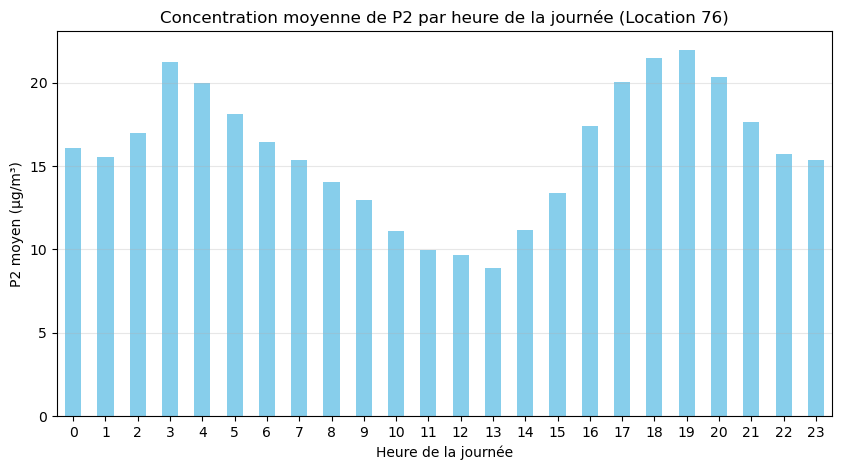

In [828]:
# Exemple 1: Moyenne de P2 par heure de la journée
import matplotlib.pyplot as plt
df_loc = final_jeux_ameliore[locations[0]]
moyenne_par_heure = df_loc.groupby('heure')['P2'].mean()

plt.figure(figsize=(10, 5))
moyenne_par_heure.plot(kind='bar', color='skyblue')
plt.title(f'Concentration moyenne de P2 par heure de la journée (Location {locations[0]})')
plt.xlabel('Heure de la journée')
plt.ylabel('P2 moyen (µg/m³)')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

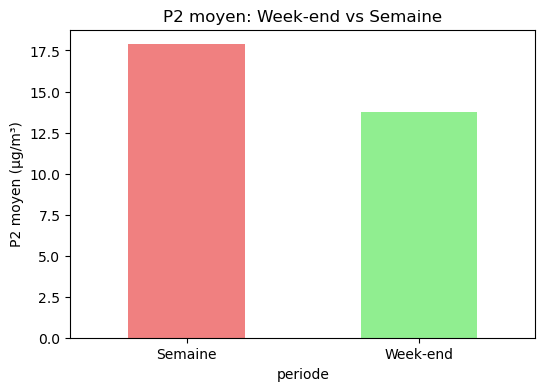

In [829]:
# Exemple 2: Comparaison week-end vs semaine
comparaison = df_loc.groupby('periode')['P2'].mean()

plt.figure(figsize=(6, 4))
comparaison.plot(kind='bar', color=['lightcoral', 'lightgreen'])
plt.title('P2 moyen: Week-end vs Semaine')
plt.ylabel('P2 moyen (µg/m³)')
plt.xticks(rotation=0)
plt.show()

In [830]:
df_loc["jour_semaine"].unique()

array(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday',
       'Sunday'], dtype=object)

In [831]:
df_loc["periode"].unique()

array(['Semaine', 'Week-end'], dtype=object)

In [832]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np

# 1. Préparer les données
all_data = []
for loc, df in final_jeux_ameliore.items():
    df_loc = df.copy()
    df_loc['heure'] = pd.to_datetime(df_loc['timestamp']).dt.hour
    hourly_mean = df_loc.groupby('heure')['P2'].mean().reset_index()
    hourly_mean['location'] = f'Loc {loc}'
    all_data.append(hourly_mean)

df_combined = pd.concat(all_data, ignore_index=True)

# 2. Calculer la moyenne globale
global_mean = df_combined.groupby('heure')['P2'].mean().reset_index()
global_mean['location'] = 'MOYENNE GLOBALE'

# 3. Créer le graphique interactif avec Plotly
fig = go.Figure()

# Palette de couleurs vives
colors = px.colors.qualitative.Vivid  # ['#E58606', '#5D69B1', '#52BCA3', '#99C945', '#CC61B0', '#24796C', '#DAA51B', '#2F8AC4']

# Ajouter chaque location
for idx, loc in enumerate(df_combined['location'].unique()):
    loc_data = df_combined[df_combined['location'] == loc]
    fig.add_trace(go.Scatter(
        x=loc_data['heure'],
        y=loc_data['P2'],
        mode='lines',
        name=loc,
        line=dict(color=colors[idx % len(colors)], width=2),
        opacity=0.7,
        hovertemplate='<b>%{text}</b><br>Heure: %{x}h<br>P2: %{y:.1f} µg/m³<extra></extra>',
        text=[loc]*len(loc_data)
    ))

# Ajouter la moyenne globale (plus épaisse)
fig.add_trace(go.Scatter(
    x=global_mean['heure'],
    y=global_mean['P2'],
    mode='lines+markers',
    name='MOYENNE GLOBALE',
    line=dict(color='#000000', width=4, dash='solid'),
    marker=dict(size=8, color='black'),
    hovertemplate='<b>Moyenne Globale</b><br>Heure: %{x}h<br>P2: %{y:.1f} µg/m³<extra></extra>'
))

# 4. Personnaliser le layout
fig.update_layout(
    title=dict(
        text='<b>ÉVOLUTION HORAIRE DE LA POLLUTION P2</b><br><span style="font-size:14px">Moyennes par location et moyenne globale</span>',
        x=0.5,
        font=dict(size=20, color='darkblue')
    ),
    xaxis=dict(
        title='<b>Heure de la journée</b>',
        tickmode='linear',
        tick0=0,
        dtick=2,
        gridcolor='lightgray',
        title_font=dict(size=14)
    ),
    yaxis=dict(
        title='<b>Concentration P2 (µg/m³)</b>',
        gridcolor='lightgray',
        title_font=dict(size=14)
    ),
    hovermode='closest',
    plot_bgcolor='white',
    paper_bgcolor='white',
    legend=dict(
        title='<b>LOCATIONS</b>',
        font=dict(size=12),
        bgcolor='rgba(240, 240, 240, 0.8)',
        bordercolor='gray',
        borderwidth=1
    ),
    height=600,
    width=900
)

# Ajouter des annotations pour les heures de pic
max_hour = global_mean.loc[global_mean['P2'].idxmax(), 'heure']
max_value = global_mean['P2'].max()
min_hour = global_mean.loc[global_mean['P2'].idxmin(), 'heure']
min_value = global_mean['P2'].min()

fig.add_annotation(
    x=max_hour, y=max_value,
    text=f"<b>Pic: {max_hour}h<br>{max_value:.1f} µg/m³</b>",
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=2,
    arrowcolor='red',
    font=dict(size=12, color='red'),
    bgcolor='rgba(255, 255, 255, 0.8)',
    bordercolor='red',
    borderwidth=1
)

fig.add_annotation(
    x=min_hour, y=min_value,
    text=f"<b>Min: {min_hour}h<br>{min_value:.1f} µg/m³</b>",
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=2,
    arrowcolor='green',
    font=dict(size=12, color='green'),
    bgcolor='rgba(255, 255, 255, 0.8)',
    bordercolor='green',
    borderwidth=1
)

# Afficher le graphique
fig.show()

#  C) Construction de nos fichiers pour l'entrainnement

## **Exportation**

In [833]:
import os
import pandas as pd

# 1. Définir les chemins et le suffixe du mois
chemins = {
    'pourcapteurs': r"C:\Users\hp\Desktop\works\donnees\pourcapteurs",
    'pourmodele': r"C:\Users\hp\Desktop\works\donnees\pourmodele",
    'pourvisuel': r"C:\Users\hp\Desktop\works\donnees\pourvisuel"
}

# 2. Créer les dossiers s'ils n'existent pas
for chemin in chemins.values():
    os.makedirs(chemin, exist_ok=True)
    print(f"✓ Dossier vérifié/créé : {chemin}")

# 3. Dictionnaire des correspondances
dictionnaires_cibles = {
    'pourcapteurs': (final_par_location, 'capteur'),
    'pourmodele': (final_jeux_complets, 'modele'),
    'pourvisuel': (final_jeux_ameliore, 'visuel')
}

# 4. Sauvegarde des fichiers
for dossier, (dictionnaire, prefixe_nom) in dictionnaires_cibles.items():
    print(f"\n💾 Sauvegarde dans '{dossier}'...")
    
    for location, df in dictionnaire.items():
        # Construire le nom de fichier
        nom_fichier = f"{prefixe_nom}_{location}_{mois}.csv"
        chemin_complet = os.path.join(chemins[dossier], nom_fichier)
        
        # Sauvegarder en CSV (séparateur et encodage par défaut)
        df.to_csv(chemin_complet, index=False)
        
        
        print(f"  ✅ {nom_fichier} ({df.shape[0]} lignes, {df.shape[1]} colonnes)")

print("\n" + "="*50)
print("✅ TOUTES LES SAUVEGARDES SONT TERMINÉES")

✓ Dossier vérifié/créé : C:\Users\hp\Desktop\works\donnees\pourcapteurs
✓ Dossier vérifié/créé : C:\Users\hp\Desktop\works\donnees\pourmodele
✓ Dossier vérifié/créé : C:\Users\hp\Desktop\works\donnees\pourvisuel

💾 Sauvegarde dans 'pourcapteurs'...
  ✅ capteur_76_Dec2025.csv (20958 lignes, 7 colonnes)
  ✅ capteur_3966_Dec2025.csv (14755 lignes, 7 colonnes)
  ✅ capteur_3967_Dec2025.csv (2921 lignes, 7 colonnes)
  ✅ capteur_3981_Dec2025.csv (21317 lignes, 7 colonnes)

💾 Sauvegarde dans 'pourmodele'...
  ✅ modele_76_Dec2025.csv (10479 lignes, 6 colonnes)
  ✅ modele_3966_Dec2025.csv (7377 lignes, 6 colonnes)
  ✅ modele_3967_Dec2025.csv (1460 lignes, 6 colonnes)
  ✅ modele_3981_Dec2025.csv (10658 lignes, 6 colonnes)

💾 Sauvegarde dans 'pourvisuel'...
  ✅ visuel_76_Dec2025.csv (10479 lignes, 12 colonnes)
  ✅ visuel_3966_Dec2025.csv (7377 lignes, 12 colonnes)
  ✅ visuel_3967_Dec2025.csv (1460 lignes, 12 colonnes)
  ✅ visuel_3981_Dec2025.csv (10658 lignes, 12 colonnes)

✅ TOUTES LES SAUVEGARDE